In [ ]:
import pandas as pd
import numpy as np

# Replace with a unique value for your team (e.g., roll number)
np.random.seed(1234)

n_days = 200
dates = pd.date_range("2024-01-01", periods=n_days)
items = ["Samosa", "Chai", "Sandwich", "Dosa", "Biryani"]

rows = []
for date in dates:
    is_weekend = date.weekday() >= 5
    is_exam = np.random.rand() < 0.15
    is_festival = np.random.rand() < 0.05
    temp = np.random.normal(28, 6)
    rainfall = max(0, np.random.normal(2, 5))

    for item in items:
        base = {"Samosa": 120, "Chai": 200, "Sandwich": 80, "Dosa": 60, "Biryani": 40}[item]
        demand = base
        demand += -15 if is_weekend else 10
        demand += 25 if is_exam else 0
        demand += 40 if is_festival else 0
        demand += (temp - 28) * 1.5 if item == "Chai" else 0
        demand -= rainfall * 2 if item in ["Dosa", "Sandwich"] else 0
        demand += np.random.normal(0, 10)
        demand = max(0, round(demand))

        rows.append([date, item, is_weekend, is_exam, is_festival,
                     round(temp, 1), round(rainfall, 1), demand])

df = pd.DataFrame(rows, columns=["date", "item", "is_weekend", "is_exam",
                                   "is_festival", "temperature", "rainfall", "units_sold"])

# Introduces missing values and invalid entries to simulate real-world data quality issues
mask = np.random.rand(len(df)) < 0.03
df.loc[mask, "temperature"] = np.nan
df.loc[df.sample(frac=0.02).index, "units_sold"] = df["units_sold"] * -1

df.to_csv("canteen_data.csv", index=False)
print(df.shape)
df.head()

(1000, 8)


,date,item,is_weekend,is_exam,is_festival,temperature,rainfall,units_sold
0,2024-01-01,Samosa,False,False,False,36.6,0.4,123
1,2024-01-01,Chai,False,False,False,36.6,0.4,232
2,2024-01-01,Sandwich,False,False,False,36.6,0.4,98
3,2024-01-01,Dosa,False,False,False,36.6,0.4,63
4,2024-01-01,Biryani,False,False,False,36.6,0.4,50


In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [ ]:
df = pd.read_csv("canteen_data.csv", parse_dates=["date"])
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         1000 non-null   datetime64[ns]
 1   item         1000 non-null   object        
 2   is_weekend   1000 non-null   bool          
 3   is_exam      1000 non-null   bool          
 4   is_festival  1000 non-null   bool          
 5   temperature  974 non-null    float64       
 6   rainfall     1000 non-null   float64       
 7   units_sold   1000 non-null   int64         
dtypes: bool(3), datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 42.1+ KB


,date,temperature,rainfall,units_sold
count,1000,974.000000,1000.000000,1000.000000
mean,2024-04-09 12:00:00,27.221253,3.101500,102.925000
min,2024-01-01 00:00:00,12.400000,0.000000,-231.000000
25%,2024-02-19 18:00:00,23.400000,0.000000,56.000000
50%,2024-04-09 12:00:00,27.050000,2.150000,87.000000
75%,2024-05-29 06:00:00,31.200000,5.300000,137.250000
max,2024-07-18 00:00:00,44.600000,15.300000,292.000000
std,NaN,5.885236,3.323883,67.465524


In [ ]:
df.shape
df.describe()
df.describe().T
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         1000 non-null   datetime64[ns]
 1   item         1000 non-null   object        
 2   is_weekend   1000 non-null   bool          
 3   is_exam      1000 non-null   bool          
 4   is_festival  1000 non-null   bool          
 5   temperature  974 non-null    float64       
 6   rainfall     1000 non-null   float64       
 7   units_sold   1000 non-null   int64         
dtypes: bool(3), datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 42.1+ KB


In [ ]:
median_val = df['temperature'].median()
df["temperature"].fillna(median_val, inplace=True)

/tmp/ipykernel_3712/1100798972.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["temperature"].fillna(median_val, inplace=True)


In [ ]:

df["units_sold"] = df["units_sold"].abs()

# Check duplicates
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate rows: 0


array([[<Axes: title={'center': 'date'}>,
        <Axes: title={'center': 'temperature'}>],
       [<Axes: title={'center': 'rainfall'}>,
        <Axes: title={'center': 'units_sold'}>]], dtype=object)

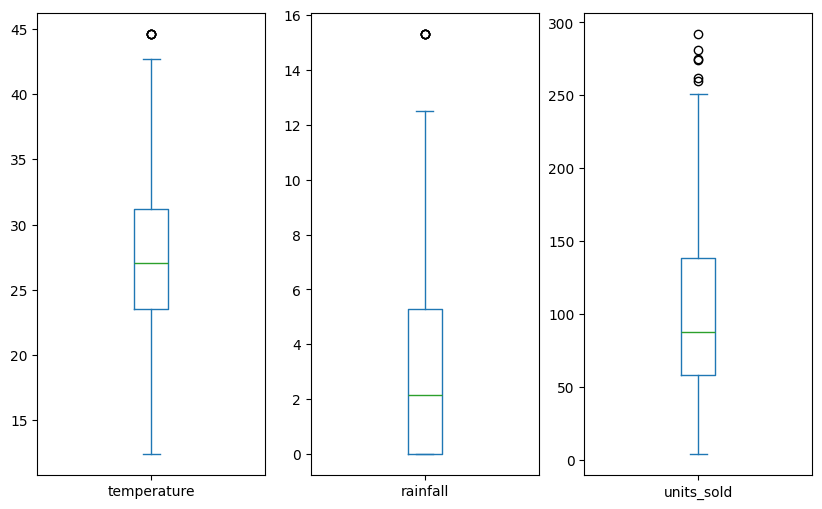

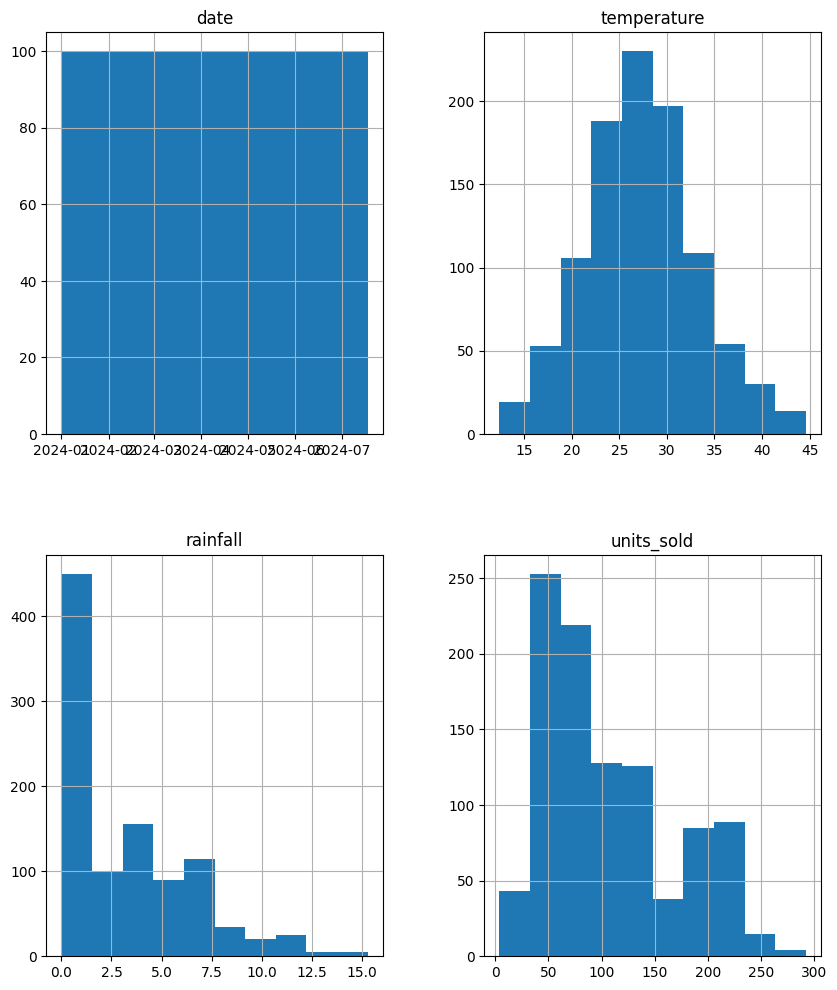

In [ ]:
df.nunique()
df.isnull().sum()
df.plot(kind="box", subplots=True, sharey=False, figsize=(10,6))
df.hist(figsize=(10,12))

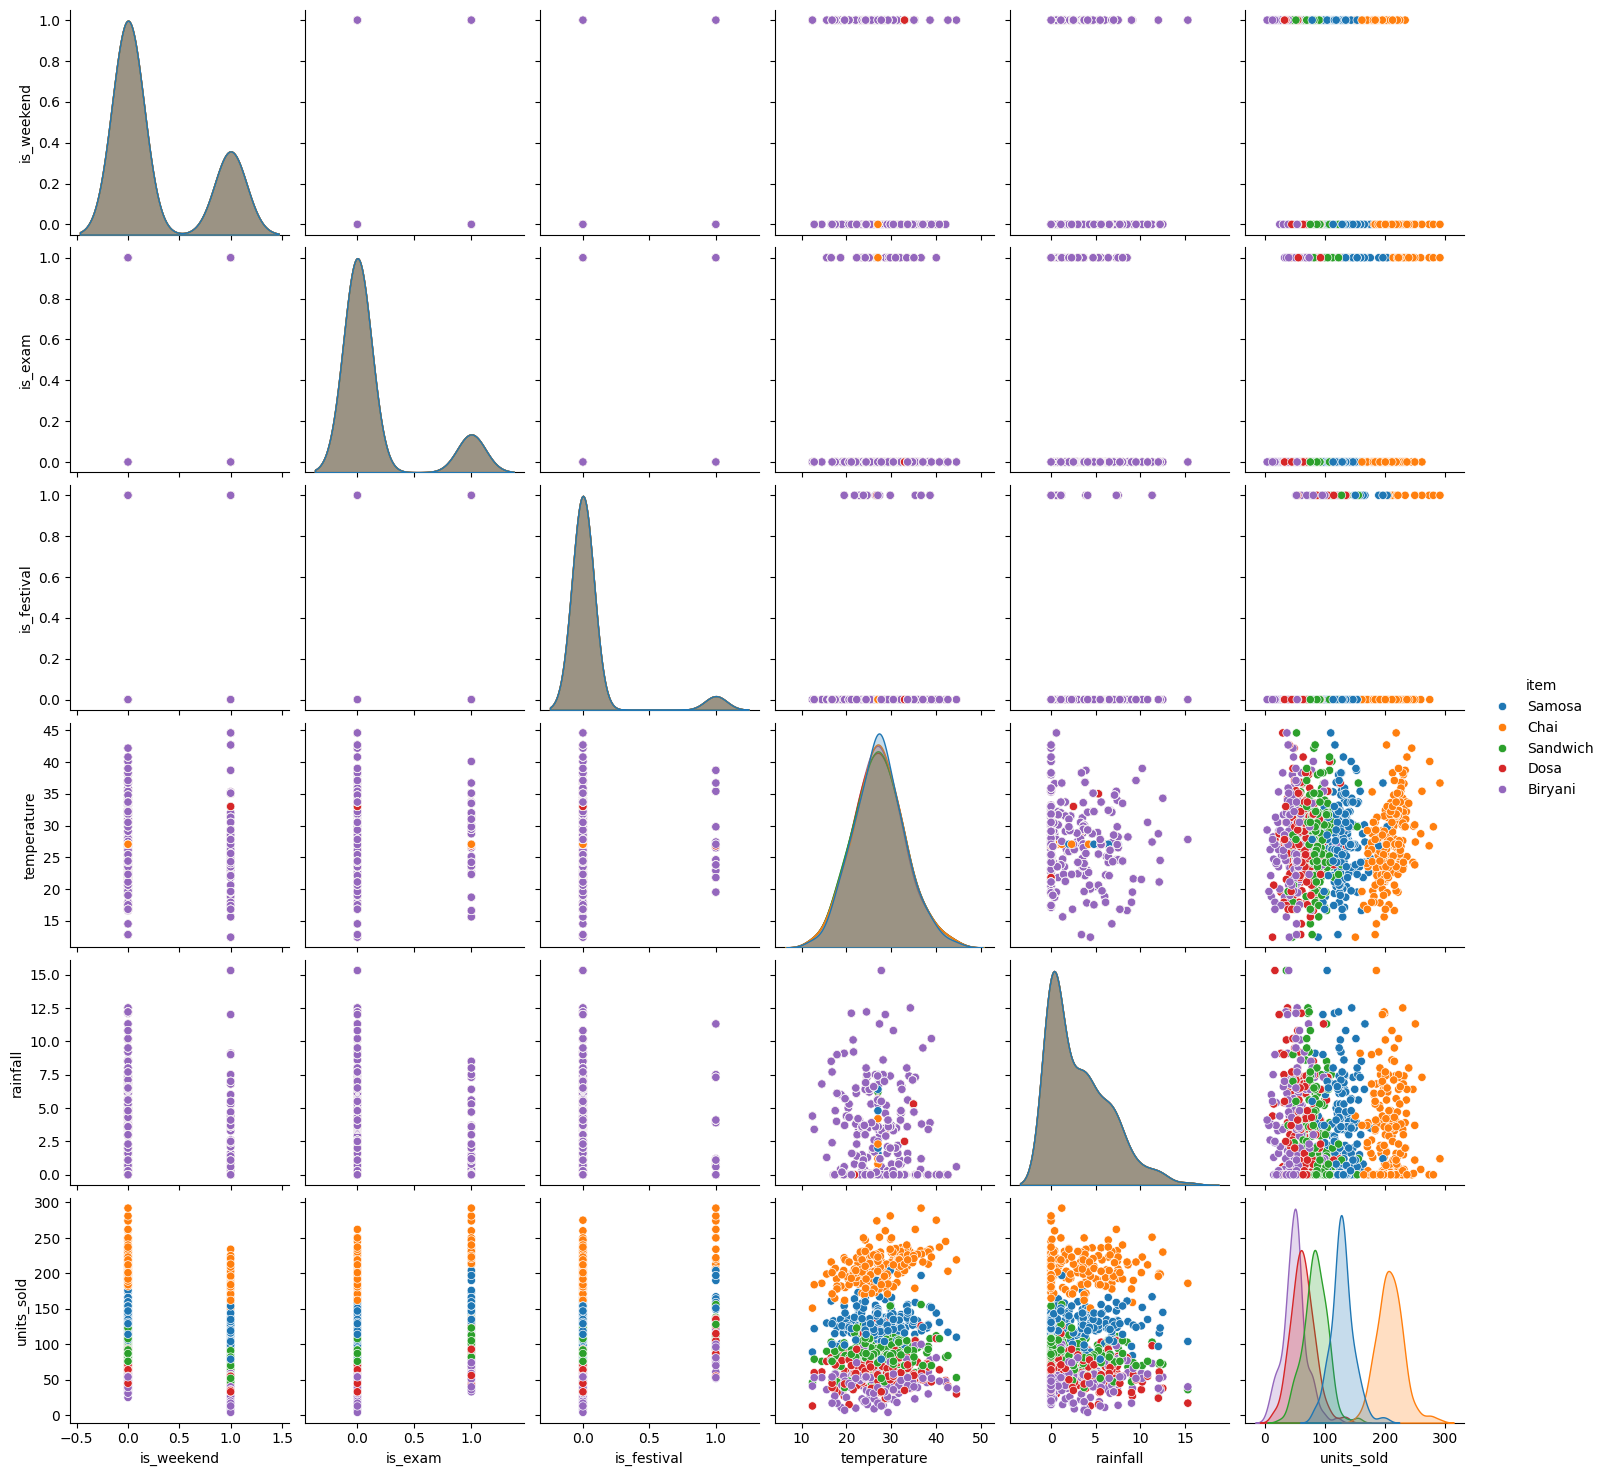

In [ ]:
sns.pairplot(df, hue='item')

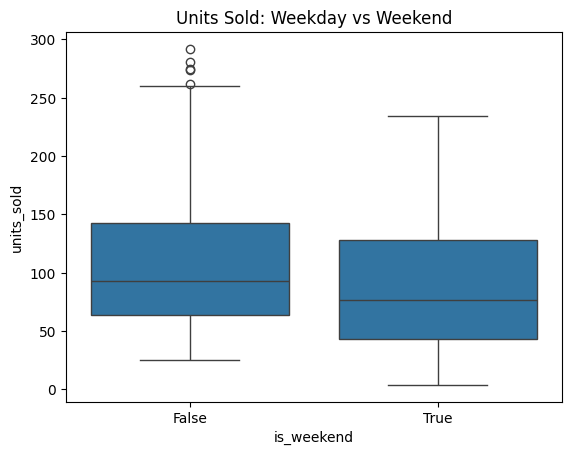

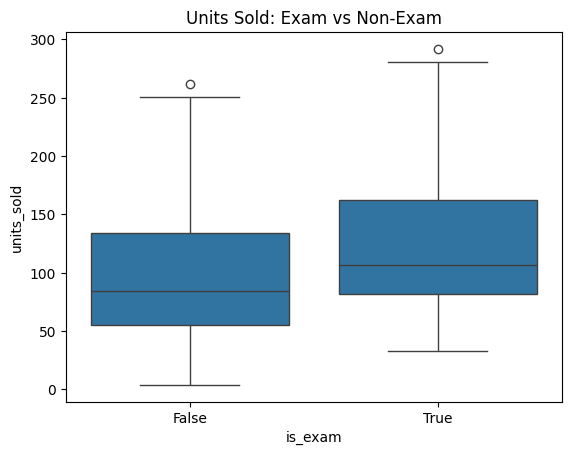

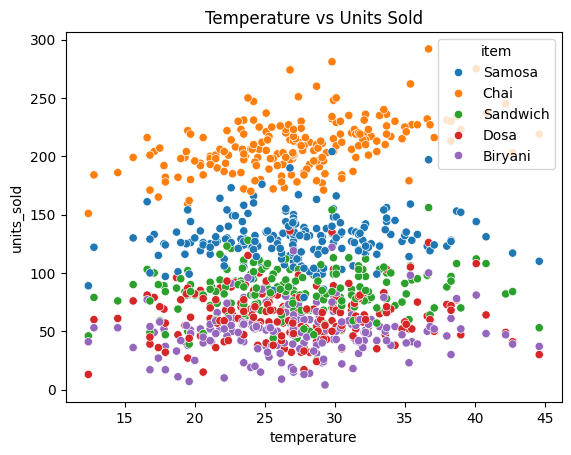

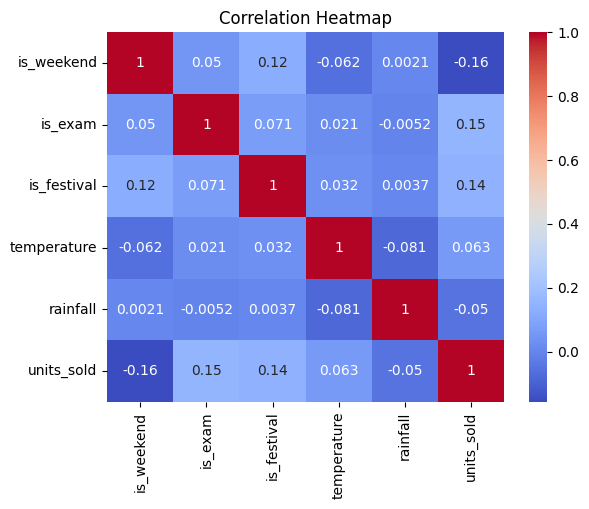

In [ ]:
sns.boxplot(x='is_weekend', y='units_sold', data=df)
plt.title('Units Sold: Weekday vs Weekend'); plt.show()

sns.boxplot(x='is_exam', y='units_sold', data=df)
plt.title('Units Sold: Exam vs Non-Exam'); plt.show()

sns.scatterplot(x='temperature', y='units_sold', hue='item', data=df)
plt.title('Temperature vs Units Sold'); plt.show()

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap'); plt.show()

In [ ]:
# Extract day_of_week and month
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month


df = df.sort_values(["item", "date"])
df["rolling_avg_7"] = (
    df.groupby("item")["units_sold"]
      .transform(lambda s: s.shift(1).rolling(7, min_periods=1).mean())
)

df["rolling_avg_7"] = df["rolling_avg_7"].fillna(
    df.groupby("item")["units_sold"].transform("mean")
)
df = df.sort_index()


df = pd.get_dummies(df, columns=["item"], drop_first=True)

df.head()

,date,is_weekend,is_exam,is_festival,temperature,rainfall,units_sold,day_of_week,month,rolling_avg_7,item_Chai,item_Dosa,item_Samosa,item_Sandwich
0,2024-01-01,False,False,False,36.6,0.4,123,0,1,128.815,False,False,True,False
1,2024-01-01,False,False,False,36.6,0.4,232,0,1,208.860,True,False,False,False
2,2024-01-01,False,False,False,36.6,0.4,98,0,1,83.785,False,False,False,True
3,2024-01-01,False,False,False,36.6,0.4,63,0,1,62.885,False,True,False,False
4,2024-01-01,False,False,False,36.6,0.4,50,0,1,49.520,False,False,False,False


In [ ]:
from sklearn.model_selection import train_test_split

x = df.drop(['units_sold', 'date'], axis=1)
y = df['units_sold']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ["temperature", "rainfall", "rolling_avg_7"]
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])  # transform only — never fit on test

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("MAE:", mae)
print("R2:", r2)
print("RMSE:", rmse)

MSE: 130.85471661957655
MAE: 9.237912068860815
R2: 0.9632088266112769
RMSE: 11.439174647656033
